#  1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import difflib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

#  2. Load Dataset

In [2]:
movies_data = pd.read_csv("movies.csv")
# Display shape
print("Shape of dataset:", movies_data.shape)

Shape of dataset: (4803, 24)


In [3]:
movies_data.head()

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


#  3. EDA (Exploratory Data Analysis)

# 3.1 Dataset Info & Missing Values

In [4]:
print ("\n Movie dataset info:")
movies_data.info()


 Movie dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 4803 non-null   int64  
 1   budget                4803 non-null   int64  
 2   genres                4775 non-null   object 
 3   homepage              1712 non-null   object 
 4   id                    4803 non-null   int64  
 5   keywords              4391 non-null   object 
 6   original_language     4803 non-null   object 
 7   original_title        4803 non-null   object 
 8   overview              4800 non-null   object 
 9   popularity            4803 non-null   float64
 10  production_companies  4803 non-null   object 
 11  production_countries  4803 non-null   object 
 12  release_date          4802 non-null   object 
 13  revenue               4803 non-null   int64  
 14  runtime               4801 non-null   float64
 15 

In [5]:
print("In the dataset check for missing values: \n ",movies_data.isnull().sum())

In the dataset check for missing values: 
  index                      0
budget                     0
genres                    28
homepage                3091
id                         0
keywords                 412
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
cast                      43
crew                       0
director                  30
dtype: int64


# 3.2 Top Movies by Revenue

In [6]:
movies_data.groupby('title')['revenue'].mean().sort_values(ascending=False).head(10)

title
Avatar                        2.787965e+09
Titanic                       1.845034e+09
The Avengers                  1.519558e+09
Jurassic World                1.513529e+09
Furious 7                     1.506249e+09
Avengers: Age of Ultron       1.405404e+09
Frozen                        1.274219e+09
Iron Man 3                    1.215440e+09
Minions                       1.156731e+09
Captain America: Civil War    1.153304e+09
Name: revenue, dtype: float64

# 3.3 Most Frequent Movies (Count)

In [7]:
movies_data.groupby('title')['revenue'].count().sort_values(ascending=False).head(10)

title
Batman                        2
Out of the Blue               2
The Host                      2
10 Cloverfield Lane           1
10 Days in a Madhouse         1
10 Things I Hate About You    1
102 Dalmatians                1
10th & Wolf                   1
11:14                         1
12 Angry Men                  1
Name: revenue, dtype: int64

# 3.4 Top 10 Movies by Budget

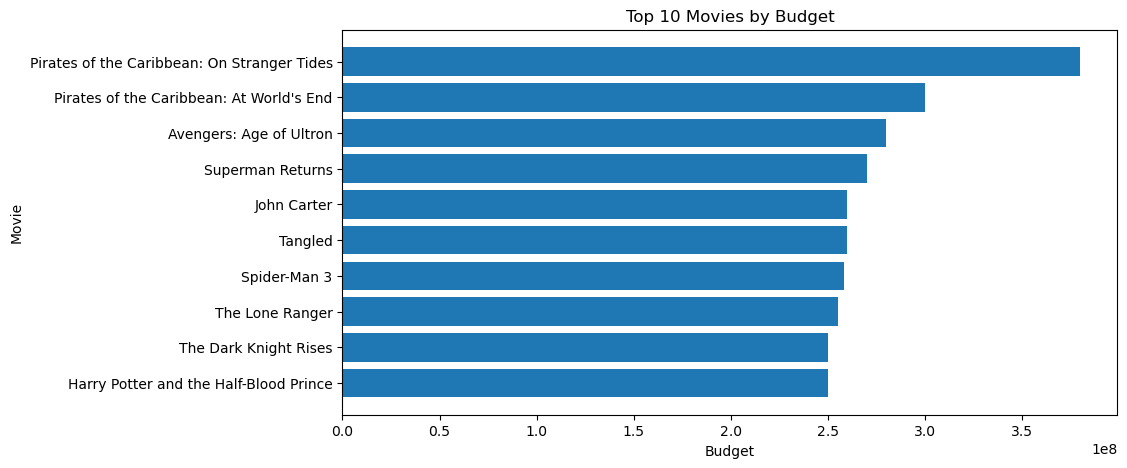

In [8]:
top_budget_movies = movies_data.nlargest(10, 'budget')[['original_title', 'budget']]

plt.figure(figsize=(10,5))
plt.barh(top_budget_movies['original_title'], top_budget_movies['budget'])
plt.xlabel("Budget")
plt.ylabel("Movie")
plt.title("Top 10 Movies by Budget")
plt.gca().invert_yaxis()
plt.show()

 # 3.5 Budget vs Revenue

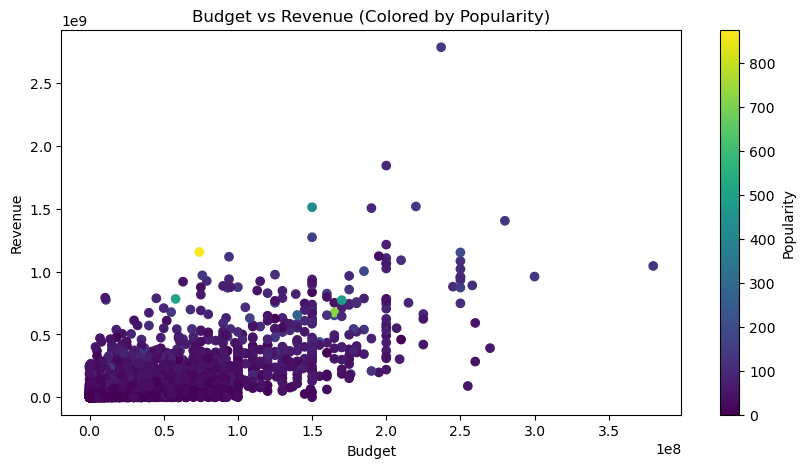

In [9]:
plt.figure(figsize=(10,5))

plt.scatter(
    movies_data['budget'],
    movies_data['revenue'],
    c=movies_data['popularity'],   # numeric values
    cmap='viridis'
)

plt.colorbar(label="Popularity")

plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.title("Budget vs Revenue (Colored by Popularity)")

plt.show()

# 3.6 Popularity Distribution

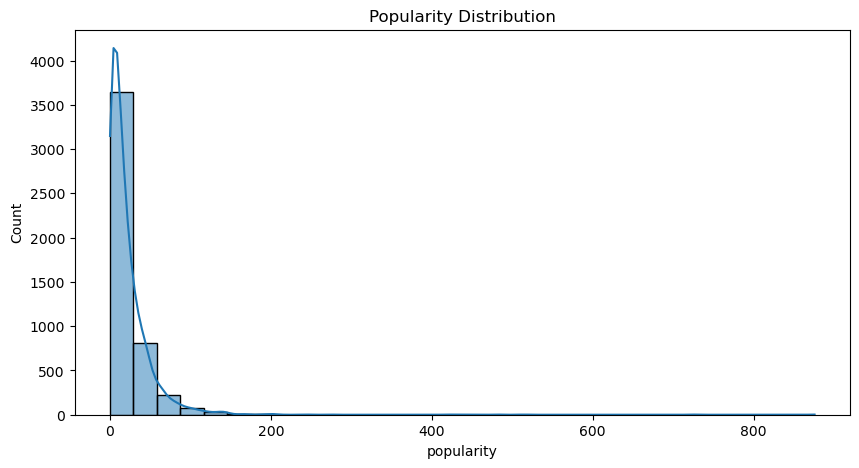

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(movies_data['popularity'], bins=30, kde=True)
plt.title("Popularity Distribution")
plt.show()

# 3.7 Average Metrics Comparison

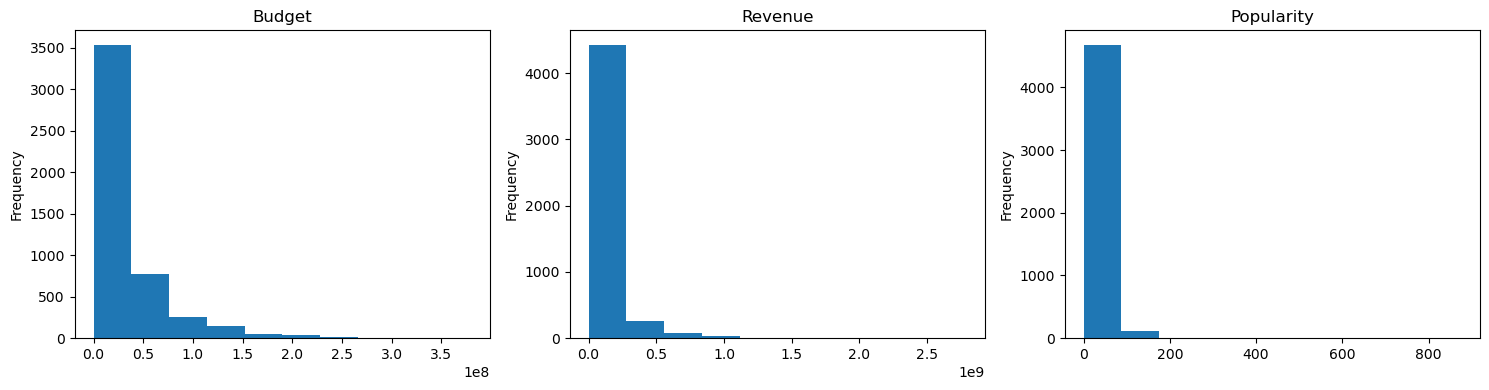

In [11]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

movies_data['budget'].plot(kind='hist', ax=axes[0], title='Budget')
movies_data['revenue'].plot(kind='hist', ax=axes[1], title='Revenue')
movies_data['popularity'].plot(kind='hist', ax=axes[2], title='Popularity')

plt.tight_layout()
plt.show()

# 4. Data Preprocessing

In [12]:
selected_features = ['genres','keywords','tagline','cast','director']

# Fill missing values
for feature in selected_features:
    movies_data[feature] = movies_data[feature].fillna('')

In [13]:
movies_data[selected_features].isnull().sum()

genres      0
keywords    0
tagline     0
cast        0
director    0
dtype: int64

# 5. Feature Engineering

In [14]:
combined_features=(movies_data['genres'] +' '+movies_data['keywords'] +' '+movies_data['tagline'] +' '+movies_data['cast'] + ' '+movies_data['director'])

# 6. Feature Extraction (TF-IDF)

In [15]:
vectorizer = TfidfVectorizer(stop_words='english')
feature_vectors = vectorizer.fit_transform(combined_features)
print("Feature Vector Shape:", feature_vectors.shape)

Feature Vector Shape: (4803, 17079)


# 7. Similarity Matrix

In [16]:
similarity = cosine_similarity(feature_vectors)
print("Similarity Matrix Shape:", similarity.shape)

Similarity Matrix Shape: (4803, 4803)


# 8. Recommendation System

In [18]:
# List of all movie titles
list_of_all_titles = movies_data['title'].tolist()
# Input movie
movie_name = input("Enter your favorite movie: ")
# Find closest match
find_close_match = difflib.get_close_matches(movie_name, list_of_all_titles)

if not find_close_match:
    print("Movie not found!")
else:
    close_match = find_close_match[0]
    index_of_movie = movies_data[movies_data.title == close_match].index[0]
    similarity_score = list(enumerate(similarity[index_of_movie]))
    sorted_similar_movies = sorted(similarity_score, key=lambda x: x[1], reverse=True)
    print("\n🎬 Movies Suggested:\n")
    
    for i, movie in enumerate(sorted_similar_movies[1:31]):
        index = movie[0]
        title = movies_data.iloc[index]['title']
        print(i+1, ".", title)

Enter your favorite movie:  Beautiful Creatures



🎬 Movies Suggested:

1 . Cape Fear
2 . Gone with the Wind
3 . Harry Potter and the Half-Blood Prince
4 . Seventh Son
5 . Poseidon
6 . Lone Star
7 . Hail, Caesar!
8 . Dragonball Evolution
9 . The Phantom of the Opera
10 . Ask Me Anything
11 . Dragonslayer
12 . Pitch Black
13 . Partition
14 . The Lovers
15 . Jesus' Son
16 . The Last Five Years
17 . The Day After Tomorrow
18 . Hellboy
19 . Doubt
20 . Hayride
21 . The Hunting Party
22 . Queen of the Damned
23 . Underworld: Evolution
24 . Harry Potter and the Goblet of Fire
25 . Slow Burn
26 . Saving Silverman
27 . The Long Kiss Goodnight
28 . E.T. the Extra-Terrestrial
29 . Living Out Loud
30 . Malevolence
